In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [27]:
import pandas as pd

df = pd.read_csv("A:\PlePrep\Projects\synthetic_crowd_3250rows.csv")
df.head()


<>:3: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:3: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\tiwar\AppData\Local\Temp\ipykernel_15260\2271753821.py:3: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  df = pd.read_csv("A:\PlePrep\Projects\synthetic_crowd_3250rows.csv")


,Person Count,Height (cm),Weight (kg),Gender,Age,Time of Day,Density Level,Occlusion Level,Clothing Color,Posture,Carrying Object,Facial Visibility,Emotion,Group Size,Distance from Camera (m),Walking Speed (m/s)
0,6,160,51,Male,44,Morning,Very High,Low,Purple,Upright,Laptop,Visible,Sad,8,26,1.34
1,20,178,93,Female,55,Afternoon,Very High,Medium,Blue,Upright,Purse,Visible,Happy,8,48,1.79
2,18,152,70,Female,15,Afternoon,Medium,High,Yellow,Mixed,Purse,Partially Visible,Neutral,8,38,1.68
3,13,161,72,Male,27,Afternoon,Low,Medium,Brown,Upright,No Object,Visible,Neutral,9,56,2.47
4,13,155,65,Female,24,Night,High,Medium,Brown,Upright,No Object,Visible,Happy,3,13,1.63


In [28]:




print("\nDATASET SHAPE:")
print(df.shape)

print("\n")
print("\nSUMMARY STATISTICS:")
print(df.describe())


print("\nMISSING VALUES:")
print(df.isnull().sum())


DATASET SHAPE:
(3250, 16)



SUMMARY STATISTICS:
       Person Count  Height (cm)  Weight (kg)          Age   Group Size  \
count   3250.000000  3250.000000  3250.000000  3250.000000  3250.000000   
mean      14.527385   166.625538    69.246769    35.503385     5.933538   
std        5.774890    12.970209    14.286628    13.890843     3.153000   
min        5.000000   145.000000    45.000000    12.000000     1.000000   
25%        9.000000   155.000000    57.000000    24.000000     3.000000   
50%       14.000000   167.000000    69.000000    36.000000     6.000000   
75%       20.000000   178.000000    81.750000    47.000000     9.000000   
max       24.000000   189.000000    94.000000    59.000000    11.000000   

       Distance from Camera (m)  Walking Speed (m/s)  
count               3250.000000          3250.000000  
mean                  31.728615             1.857455  
std                   15.870403             0.396712  
min                    5.000000             0.630000  

In [29]:
# NORMAL DATA CLEANING

# Copy dataframe to keep original safe
clean_df = df.copy()

# Numerical columns
num_cols = ['Height (cm)', 'Weight (kg)']

# Categorical columns
cat_cols = ['Time of Day']

# -------------------------------
# 1) Fill numerical missing values with median
# -------------------------------
clean_df['Height (cm)'] = clean_df['Height (cm)'].fillna(clean_df['Height (cm)'].median())
clean_df['Weight (kg)'] = clean_df['Weight (kg)'].fillna(clean_df['Weight (kg)'].median())

# -------------------------------
# 2) Fill categorical missing values with mode
# -------------------------------
clean_df['Time of Day'] = clean_df['Time of Day'].fillna(clean_df['Time of Day'].mode()[0])

print("Missing values after cleaning:")
print(clean_df.isnull().sum())


Missing values after cleaning:
Person Count                0
Height (cm)                 0
Weight (kg)                 0
Gender                      0
Age                         0
Time of Day                 0
Density Level               0
Occlusion Level             0
Clothing Color              0
Posture                     0
Carrying Object             0
Facial Visibility           0
Emotion                     0
Group Size                  0
Distance from Camera (m)    0
Walking Speed (m/s)         0
dtype: int64


Visualization

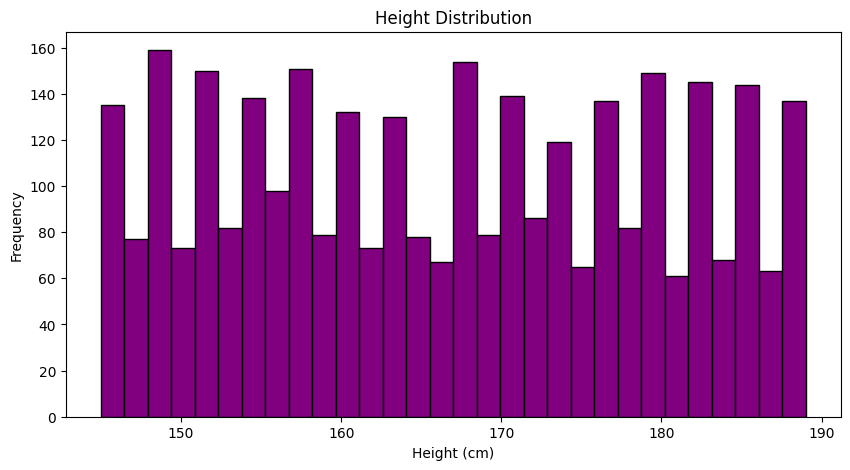

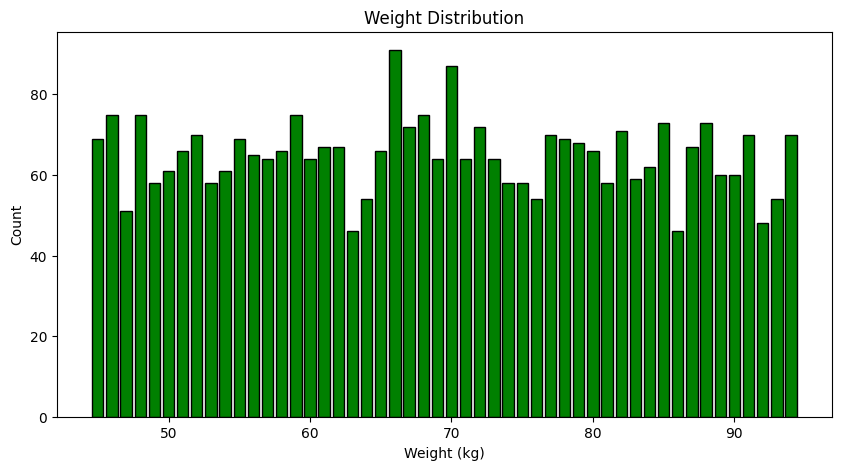

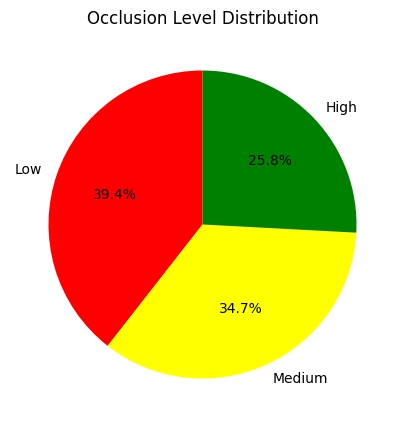

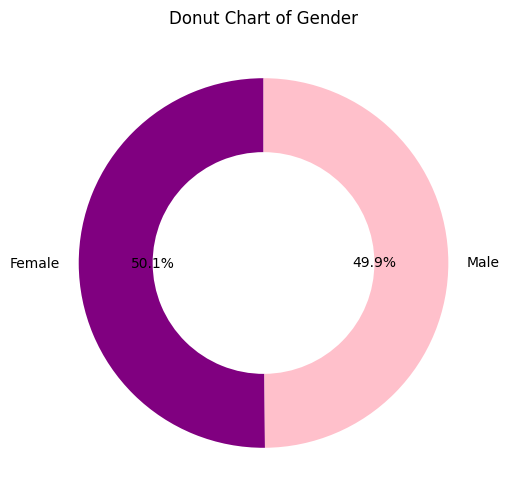

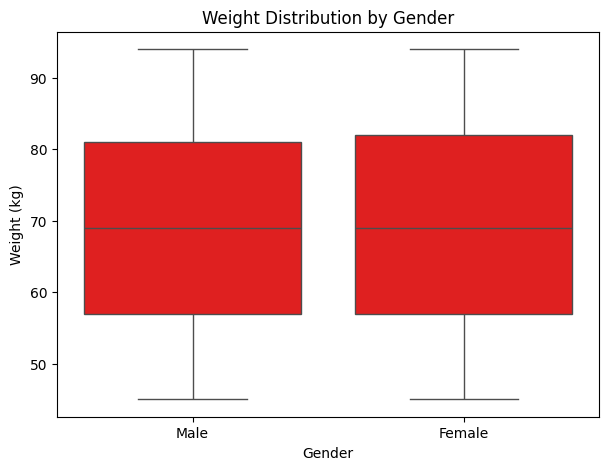

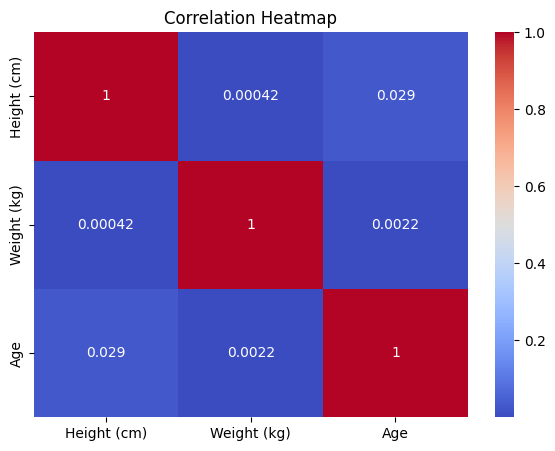

Weight (kg) outliers removed. New shape: (3250, 16)


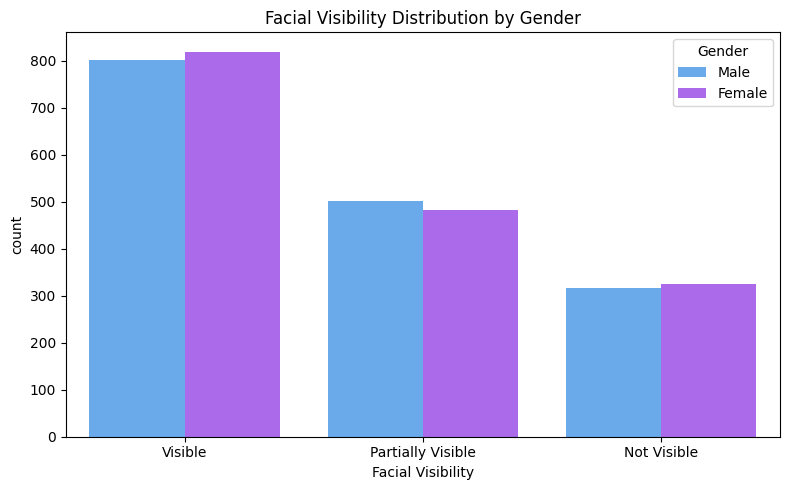

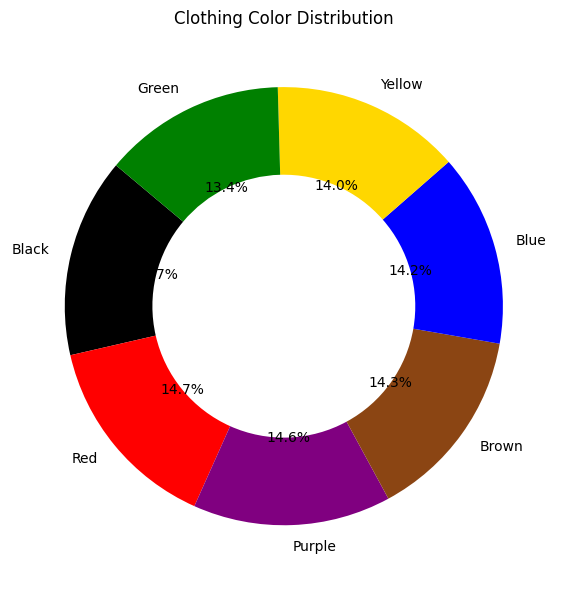

In [30]:
# 1. Height Distribution
plt.figure(figsize=(10, 5))
plt.hist(df['Height (cm)'], bins=30, color='purple', edgecolor='black')
plt.title('Height Distribution')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.show()

# 2. Weight Distribution (Bar)
value_counts = df['Weight (kg)'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(value_counts.index, value_counts.values, color='green', edgecolor='black')
plt.title('Weight Distribution')
plt.xlabel('Weight (kg)')
plt.ylabel('Count')
plt.show()

# 3. Occlusion Level Pie Chart
colors = ['red', 'yellow', 'green']

plt.figure(figsize=(5, 5))
df['Occlusion Level'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
plt.title('Occlusion Level Distribution')
plt.ylabel('')
plt.show()

# 4. Gender Donut Chart
counts = df['Gender'].value_counts()
colors = ['purple', 'pink', 'moccasin']

plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'width': 0.4}
)
plt.title('Donut Chart of Gender')
plt.show()

# -------------------------------
# BIVARIATE / MULTIVARIATE
# -------------------------------

# 1. Gender vs Weight (Boxplot)
plt.figure(figsize=(7, 5))
sns.boxplot(x='Gender', y='Weight (kg)', data=df, color='red')
plt.title('Weight Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Weight (kg)')
plt.show()


# 3. Correlation Heatmap
num_subset = df[['Height (cm)', 'Weight (kg)', 'Age']]

plt.figure(figsize=(7, 5))
sns.heatmap(num_subset.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# -------------------------------
# OUTLIER REMOVAL (WEIGHT)
# -------------------------------
col = 'Weight (kg)'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
print(f"{col} outliers removed. New shape: {df.shape}")

# -------------------------------
# Facial Visibility by Gender
# -------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(x='Facial Visibility', hue='Gender', data=df, palette='cool')
plt.title('Facial Visibility Distribution by Gender')
plt.tight_layout()
plt.show()

# -------------------------------
# Clothing Color Pie Donut
# -------------------------------
color_map = {
    'Red': 'red', 'Green': 'green', 'Blue': 'blue', 'Yellow': 'gold',
    'Pink': 'pink', 'Purple': 'purple', 'Black': 'black',
    'White': 'whitesmoke', 'Orange': 'orange', 'Brown': 'saddlebrown'
}

counts = df['Clothing Color'].value_counts()
labels = counts.index
colors = [color_map.get(label, 'grey') for label in labels]

plt.figure(figsize=(6, 6))
plt.pie(
    counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.4)
)
plt.title('Clothing Color Distribution')
plt.tight_layout()
plt.show()

FEATURE ENGINEERING 

In [35]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(r"A:\PlePrep\Projects\synthetic_crowd_3250rows.csv")

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        print("Encoding:", col)
        df[col] = le.fit_transform(df[col].astype(str))

df.head()


Encoding: Gender
Encoding: Time of Day
Encoding: Density Level
Encoding: Occlusion Level
Encoding: Clothing Color
Encoding: Posture
Encoding: Carrying Object
Encoding: Facial Visibility
Encoding: Emotion


,Person Count,Height (cm),Weight (kg),Gender,Age,Time of Day,Density Level,Occlusion Level,Clothing Color,Posture,Carrying Object,Facial Visibility,Emotion,Group Size,Distance from Camera (m),Walking Speed (m/s)
0,6,160,51,1,44,2,3,1,4,3,1,2,2,8,26,1.34
1,20,178,93,0,55,0,3,2,1,3,3,2,0,8,48,1.79
2,18,152,70,0,15,0,2,0,6,1,3,1,1,8,38,1.68
3,13,161,72,1,27,0,1,2,2,3,2,2,1,9,56,2.47
4,13,155,65,0,24,3,0,2,2,3,2,2,0,3,13,1.63


In [32]:
print(df["Walking Speed (m/s)"].head())
print(df["Walking Speed (m/s)"].dtype)


0    1.34
1    1.79
2    1.68
3    2.47
4    1.63
Name: Walking Speed (m/s), dtype: float64
float64


In [33]:
df.columns

Index(['Person Count', 'Height (cm)', 'Weight (kg)', 'Gender', 'Age',
       'Time of Day', 'Density Level', 'Occlusion Level', 'Clothing Color',
       'Posture', 'Carrying Object', 'Facial Visibility', 'Emotion',
       'Group Size', 'Distance from Camera (m)', 'Walking Speed (m/s)'],
      dtype='object')

Model Creation

In [ ]:
#REGRESSION
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=["Walking Speed (m/s)"])
y = df["Walking Speed (m/s)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))


R2 Score: 0.9329556613282108
RMSE: 0.10128802541420028


In [ ]:
#CLASSIFICATIO
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df["Speed_Class"] = (df["Walking Speed (m/s)"] > df["Walking Speed (m/s)"].mean()).astype(int)

y_cls = df["Speed_Class"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_cls, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train_c, y_train_c)

pred_c = clf.predict(X_test_c)

print("Classification Accuracy:", accuracy_score(y_test_c, pred_c))



Classification Accuracy: 0.8953846153846153
